<a href="https://colab.research.google.com/github/ddsntc1/Visual_information_extraction/blob/main/look_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers datasets seqeval
!wget https://aistages-api-public-prod.s3.amazonaws.com/app/Competitions/000230/data/data.tar.gz
!wget https://aistages-api-public-prod.s3.amazonaws.com/app/Competitions/000230/data/code.tar.gz
!tar -xvzf data.tar.gz
!tar -xvzf code.tar.gz
!rm code.tar.gz data.tar.gz
!mv code/* data/

In [ ]:
import json
from glob import glob
from datasets import Dataset, DatasetDict, Features, Sequence, Value, Image, ClassLabel
import json


try2 = ['train','test']
for targ in try2:

  # 파일 경로
  txt_path = f"data/{targ}.txt"
  box_path = f"data/{targ}_box.txt"
  image_path = f"data/{targ}_image.txt"
  image_folder = f"data/{targ}/img/"

  dataset = []

  # 파일 읽기
  with open(txt_path, "r", encoding="utf-8") as txt_file, \
      open(box_path, "r", encoding="utf-8") as box_file, \
      open(image_path, "r", encoding="utf-8") as image_file:

      txt_lines = txt_file.readlines()
      box_lines = box_file.readlines()
      image_lines = image_file.readlines()
      words = []
      bboxes = []
      norm_bboxes = []
      labels = []
      image_info = None
      max_x = max_y = None

      for txt_line, box_line, image_line in zip(txt_lines, box_lines, image_lines):
          if txt_line.strip() == "" or box_line.strip() == "" or image_line.strip() == "":
              if image_info:
                  dataset.append({
                      "words": words,
                      "bboxes": bboxes,
                      "norm_bboxes": norm_bboxes,
                      "labels": labels,
                      "image_path": f"{image_folder}{image_info}.jpg",
                      "max_x": max_x,
                      "max_y": max_y,
                      "file_name" : image_info #--
                  })

              # 초기화
              words = []
              bboxes = []
              norm_bboxes = []
              labels = []
              image_info = None
              max_x = max_y = None
              continue

          word, bio_tag = txt_line.strip().split('\t')
          label = bio_tag

          box_parts = box_line.strip().split()
          normalised_bbox = list(map(float, box_parts[-4:]))

          image_parts = image_line.strip().split()
          img_name = image_parts[-1]
          width, height = int(image_parts[-3]), int(image_parts[-2])
          bbox = list(map(float, image_parts[-7:-3])) # x0,y0,x1,y1

          if image_info is None:
              image_info = img_name
              max_x = width
              max_y = height

          words.append(word)
          norm_bboxes.append(normalised_bbox)
          bboxes.append(bbox)
          labels.append(label)

  # 마지막 이미지 정보 저장
  if image_info:
      dataset.append({
          "words": words,
          "bboxes": bboxes,
          "norm_bboxes": norm_bboxes,  # 마지막에도 norm_bboxes 추가
          "labels": labels,
          "image_path": f"{image_folder}{image_info}.jpg",
          "max_x": max_x,
          "max_y": max_y,
          "file_name" : image_info #--
      })

  # JSON 파일로 저장
  with open(f"{targ}_dataset.json", "w", encoding="utf-8") as json_file:
      json.dump(dataset, json_file, ensure_ascii=False, indent=4)


# train과 test JSON 파일 경로
train_json_path = "train_dataset.json"
test_json_path = "test_dataset.json"
label2id = {"S-COMPANY": 0, "S-DATE": 1, "S-ADDRESS": 2, "S-TOTAL": 3, "O": 4}
# JSON 파일 불러오기
with open(train_json_path, "r", encoding="utf-8") as f:
    train_data = json.load(f)

with open(test_json_path, "r", encoding="utf-8") as f:
    test_data = json.load(f)

features = Features({
    'image': Image(),  # 이미지를 직접 파일 경로로 불러오기
    'label': Sequence(feature=ClassLabel(num_classes=5, names=["S-COMPANY", "S-DATE","S-ADDRESS", "S-TOTAL", "O"], id=None), length=-1, id=None),
    'words': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None),
    'bbox': Sequence(feature=Sequence(feature=Value(dtype='int64', id=None), length=-1, id=None), length=-1, id=None),
    'filename': Value(dtype='string', id=None), #--
})

# 파일 경로만 유지하며 데이터셋 생성
train_formatted_data = {
    "image": [item["image_path"] for item in train_data],
    "label": [item["labels"] for item in train_data],
    "words": [item["words"] for item in train_data],
    "bbox": [item["bboxes"] for item in train_data],
    "filename" : [item["file_name"] for item in train_data] #--
}

test_formatted_data = {
    "image": [item["image_path"] for item in test_data],
    "label": [item["labels"] for item in test_data],
    "words": [item["words"] for item in test_data],
    "bbox": [item["bboxes"] for item in test_data],
    "filename" : [item["file_name"] for item in test_data] #--
}
train_dataset = Dataset.from_dict(train_formatted_data, features=features)
test_dataset = Dataset.from_dict(test_formatted_data, features=features)

# DatasetDict
dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'words', 'bbox', 'filename'],
        num_rows: 626
    })
    test: Dataset({
        features: ['image', 'label', 'words', 'bbox', 'filename'],
        num_rows: 347
    })
})


In [ ]:
from PIL import Image, ImageDraw, ImageFont

def show_img(n, targ='train'):
    xy = []
    lab = []
    img_name = dataset[targ][n]['filename']
    for i in range(len(dataset[targ][n]['words'])):
        x0, y0, x1, y1 = dataset[targ][n]['bbox'][i]
        bio = dataset[targ][n]['label'][i]
        xy.append([x0,y0,x1,y1])
        lab.append(bio)

    image = Image.open(f'data/{targ}/img/{img_name}.jpg')
    label2color = {
        0: 'black',   # Company
        1: 'blue',    # Date
        2: 'green',   # Address
        3: 'orange',  # total
        4: 'violet'   # O
    }

    draw = ImageDraw.Draw(image, "RGB")
    for i, box in enumerate(xy):
        draw.rectangle(box, outline=label2color[lab[i]], width=2)

    return image.resize((300,600))

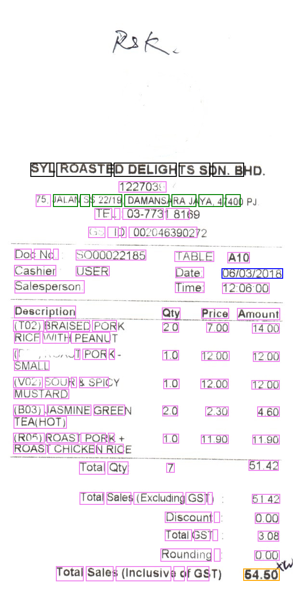

In [ ]:
show_img(20,'train')